## Results analysis

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

Aggregate the results.

In [2]:
def translate_dataset(dataset):
    if dataset == "cifar10":
        return "CIFAR10"
    elif dataset == "mnist":
        return "MNIST"
    elif dataset == "fashion-mnist":
        return "FashionMNIST"
    raise NameError(f"Unsupported dataset: {dataset}")

def translate_method(method):
    if method == "selective-fd":
        return "Selective-FD"
    elif method == "fed-md":
        return "FedMD"
    elif method == "weighted-fd":
        return "Weighted-FD"
    else:
        raise NameError(f"Unsupported method: {method}")
    
    
RESULTS_PATH = os.path.join("..", "ignore", "outputs", "proxy-fraction")

aggregated_data = []
proxy_fractions = set()

for dirname in os.listdir(RESULTS_PATH):
    tokens = dirname.split('_')

    algorithm = translate_method(tokens[0])
    dataset = translate_dataset(tokens[1])
    dataset_type = tokens[-3]
    seed = tokens[-2]
    proxy_fraction = tokens[-1]
    proxy_fractions.add(proxy_fraction)
    for client_idx in range(10):
        client_log = os.path.join(RESULTS_PATH, dirname, 'logs', f'client-{client_idx}.csv')
        client_log = pd.read_csv(client_log)

        # add more fields
        client_log["client"] = np.repeat(client_idx, len(client_log))
        client_log["algorithm"] = np.repeat(algorithm, len(client_log))
        client_log["dataset"] = np.repeat(dataset, len(client_log))
        client_log["dataset_type"] = np.repeat(dataset_type, len(client_log))
        client_log["seed"] = np.repeat(seed, len(client_log))
        client_log["proxy_fraction"] = np.repeat(proxy_fraction, len(client_log))

        aggregated_data.append(client_log)

df = pd.concat(aggregated_data, axis=0).reset_index(drop=True)
df.to_csv(os.path.join("..", "ignore", "aggregated_results.csv"), index=False)
df.head()

,round,mode,accuracy,precision,recall,f1,client,algorithm,dataset,dataset_type,seed,proxy_fraction
0,0,valid,0.665833,0.742584,0.665833,0.633055,0,Weighted-FD,FashionMNIST,hni,27,0.8
1,0,test,0.651000,0.663043,0.651000,0.622788,0,Weighted-FD,FashionMNIST,hni,27,0.8
2,1,valid,0.700833,0.703706,0.700833,0.678572,0,Weighted-FD,FashionMNIST,hni,27,0.8
3,1,test,0.700900,0.692626,0.700900,0.684463,0,Weighted-FD,FashionMNIST,hni,27,0.8
4,2,valid,0.736667,0.738308,0.736667,0.724391,0,Weighted-FD,FashionMNIST,hni,27,0.8


Compare the accuracy:

In [3]:
table_data = []

for dataset_type in df.dataset_type.unique():
    
    current_df = df[df.dataset_type == dataset_type]
    current_df_groups = current_df.groupby(["algorithm", "dataset", "proxy_fraction"])
    
    for group_key in current_df_groups.groups:
        group = current_df_groups.get_group(group_key)
        
        accuracies = []
        
        group_valid = group[ group["mode"] == "valid" ]
        for seed in group_valid.seed.unique():
        
            # # group by rounds, average clients F1 scores per round
            # seed_df = group_valid[ group_valid.seed == seed ] \
            #     .groupby(["round"]).f1.mean().reset_index()
        
            # # select the round with the highest validation F1 score
            # best_valid_round = seed_df[ seed_df.f1 == seed_df.f1.max() ] \
            #     .iloc[0]["round"].astype(int)
            
            # select the client accuracies at the given seed and round
            # and average across the clients to get the seed's best accuracy
            best_test_acc = group[ (group["mode"]  == "test") & \
                                   (group["seed"]  == seed)   & \
                                   (group["round"] == group["round"].max()) ].accuracy.mean()
        
            if np.isnan(best_test_acc):
                continue

            accuracies.append(best_test_acc)
        
        accuracies = np.array(accuracies)
        
        algorithm, dataset, proxy_fraction = group_key
        
        table_data.append({
            'algorithm': algorithm,
            'dataset': dataset,
            "proxy_fraction": proxy_fraction,
            'dataset_type': dataset_type,
            'accuracy': (np.mean(accuracies) * 100), 
            'std_accuracy': (np.std(accuracies) * 100),
            'accuracies': ', '.join([ str(round(a, 3)) for a in accuracies ])
        })
    
scores = pd.DataFrame(table_data)


scores['score'] = scores.groupby(['dataset_type', 'dataset', "proxy_fraction"])['accuracy'].rank(ascending=False)
scores.sort_values(["dataset", "dataset_type",  "proxy_fraction", "accuracy"], ascending=True, inplace=True)

scores


,algorithm,dataset,proxy_fraction,dataset_type,accuracy,std_accuracy,accuracies,score
0,FedMD,CIFAR10,0.2,hni,18.2262,3.034320,"0.197, 0.235, 0.164, 0.154, 0.161",3.0
12,Selective-FD,CIFAR10,0.2,hni,29.6002,3.058492,"0.277, 0.248, 0.303, 0.316, 0.335",2.0
24,Weighted-FD,CIFAR10,0.2,hni,64.7612,0.538470,"0.649, 0.654, 0.641, 0.642, 0.652",1.0
1,FedMD,CIFAR10,0.4,hni,15.6690,0.549649,"0.166, 0.154, 0.158, 0.154, 0.15",3.0
13,Selective-FD,CIFAR10,0.4,hni,36.6706,4.799647,"0.417, 0.416, 0.32, 0.301, 0.38",2.0
...,...,...,...,...,...,...,...,...
46,FedMD,MNIST,0.6,wni,96.4436,0.120026,"0.965, 0.966, 0.964, 0.964, 0.963",2.0
70,Weighted-FD,MNIST,0.6,wni,97.9004,0.243188,"0.977, 0.982, 0.979, 0.975, 0.982",1.0
59,Selective-FD,MNIST,0.8,wni,96.4166,0.061053,"0.964, 0.965, 0.964, 0.963, 0.964",3.0
47,FedMD,MNIST,0.8,wni,96.4300,0.062389,"0.965, 0.964, 0.963, 0.964, 0.965",2.0


In [4]:
import numpy as np

def generate_accuracy_table(df, proxy_fraction: float):
    # Define the dataset types and their corresponding labels
    dataset_types = {
        'iid': 'IID',
        'wni': 'WNI',
        'hni': 'SNI',
    }
    
    # Initialize the LaTeX table string
    latex_table = r"""
\begin{table*}[ht]
    \centering
    \renewcommand{\arraystretch}{1.6} % Uniform row height
    \setlength{\tabcolsep}{12pt}      % Uniform column spacing
    \small                            % Uniform font size

    \begin{tabular}{c|l|ccc}
        \hline
        & \textbf{Method} & \textbf{MNIST} & \textbf{Fashion MNIST} & \textbf{CIFAR-10}\\ 
        \hline
"""
    citations = {
        'FedMD':        '~\cite{fedmd}', 
        'Selective-FD': '~\cite{selective_fd}', 
        'Weighted-FD':  ' (Proposed)',
    }
    
    
    # Group the dataframe by dataset_type and iterate over each group
    for dataset_type, dataset_type_str in dataset_types.items():
        group = df[ df.dataset_type == dataset_type ]
        group = group[group["proxy_fraction"] == proxy_fraction]

        bold_dataset_type_str = f"\\textbf{{{dataset_type_str}}}"
        latex_table += f"        \\multirow{{3}}{{*}}{{\\rotatebox[origin=c]{{90}}{{{bold_dataset_type_str}}}}}\n"
        
        # Iterate over each algorithm in the group
        for algorithm, citation in citations.items():
            latex_table += f"        & {algorithm.replace('-', ' ')}{citation}"
            
            # Iterate over each dataset and calculate the mean and std deviation of accuracies
            for dataset in  ["MNIST", "FashionMNIST", "CIFAR10"]:
                # accuracies = group[(group['algorithm'] == algorithm) & (group['dataset'] == dataset)]['accuracies']
                # if not accuracies.empty:
                #     accuracies = list(map(float, accuracies.iloc[0].split(', ')))
                #     mean_accuracy = np.mean(accuracies) * 100
                #     std_accuracy = np.std(accuracies) * 100
                #     latex_table += f" & {mean_accuracy:.2f} $\\pm$ {std_accuracy:.2f}"
                # else:
                #     latex_table += " & -"
                
                accuracy = group[(group['algorithm'] == algorithm) & (group['dataset'] == dataset)]['accuracy']
                std_accuracy = group[(group['algorithm'] == algorithm) & (group['dataset'] == dataset)]['std_accuracy']
                score = group[(group['algorithm'] == algorithm) & (group['dataset'] == dataset)]['score']
                
                if accuracy is not None and len(accuracy) > 0:
                    score = int(score.iloc[0])
                    if score == 1:
                        latex_table += f" & \\textbf{{{accuracy.iloc[0]:.2f} $\\pm$ {std_accuracy.iloc[0]:.2f}}}"
                    elif score == 2:
                        latex_table += f" & \\underline{{{accuracy.iloc[0]:.2f} $\\pm$ {std_accuracy.iloc[0]:.2f}}}"
                    else:
                        latex_table += f" & {accuracy.iloc[0]:.2f} $\\pm$ {std_accuracy.iloc[0]:.2f}"
                    
                else:
                    latex_table += " & - "
            latex_table += " \\\\\n"
        
        latex_table += "        \\hline\n"
    
    # Close the LaTeX table string
    latex_table += fr"""
    \end{{tabular}}
    \caption{{Experiments evaluating a proxy fraction of {proxy_fraction}. Bold values highlight the best performance, while underlined values indicate the second-best. In the non-\acrshort{{iid}} settings, which are the focus of our study, the Weighted-FD method consistently outperforms baseline methods on both the MNIST and FashionMNIST datasets.}}
    \label{{tab:test_results_{proxy_fraction}}}
\end{{table*}}
"""

    
    return latex_table

for proxy_fraction in sorted(proxy_fractions):
    
    # Generate the LaTeX table
    latex_table = generate_accuracy_table(scores, proxy_fraction)
    #print(latex_table)

    # Save the LaTeX table to a .tex file
    with open(os.path.join("..", "ignore", f'accuracy_table_{proxy_fraction}.tex'), 'w') as f:
        f.write(latex_table)

print("LaTeX table saved to accuracy_table.tex")



LaTeX table saved to accuracy_table.tex


Plot the convergence

In [5]:
def plot_convergence(plot_df, range_builder):
    _, ax = plt.subplots(ncols=3, figsize=(15, 4))

    for i, (dataset_type, dataset_type_label)in enumerate(zip(['iid', 'wni', 'hni'], ["IID", "WNI", "SNI"] )):
        ax[i].set_title(dataset_type_label, weight="bold")
        _range = range_builder(dataset_type)
       # _range = [0.6, 0.8] if dataset_type != 'hni' else [0., 0.8]
       # _range = [0.94, 1.00] if dataset_type != 'hni' else [0., 1.00]
        ax[i].set_ylim(_range) 
        
        curr_df = plot_df[plot_df.dataset_type == dataset_type]
        curr_df = curr_df[ curr_df['round'] == curr_df['round'].max() ]
        sns.lineplot(data=curr_df, 
                    x="proxy_fraction", 
                    y="accuracy", 
                    hue="algorithm",
                    ax=ax[i], 
                    palette="twilight")

    plt.show()

Plot MNIST convergence

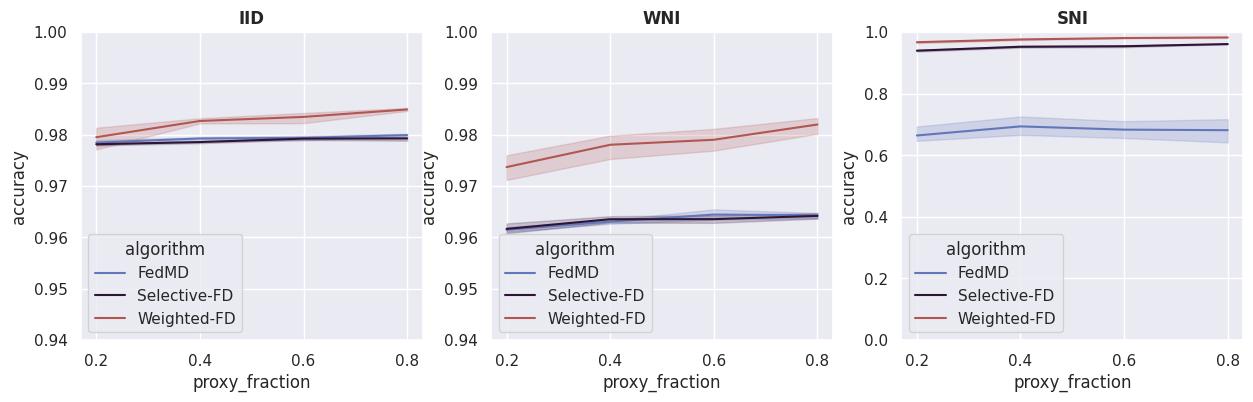

In [6]:
mnist_plot_df = df[ (df["mode"] == "test") & (df["dataset"] == "MNIST") ]  \
            .groupby(["round", "algorithm", "dataset_type", "seed", "proxy_fraction"]) \
            .accuracy.mean().reset_index()
    
plot_convergence(mnist_plot_df, lambda dataset_type : [0.94, 1.00] if dataset_type != 'hni' else [0., 1.00])

Plot FashionMNIST convergence

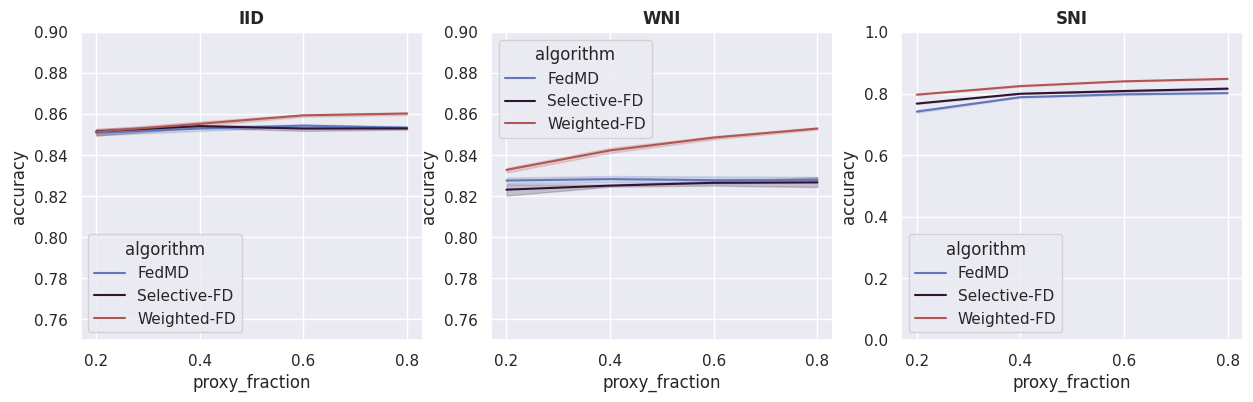

In [7]:
fashion_plot_df = df[ (df["mode"] == "test") & (df["dataset"] == "FashionMNIST") ]  \
            .groupby(["round", "algorithm", "dataset_type", "seed", "proxy_fraction"]) \
            .accuracy.mean().reset_index()
            
plot_convergence(fashion_plot_df, lambda dataset_type : [0.75, 0.90] if dataset_type != 'hni' else [0., 1.00])

Plot CIFAR10 convergence

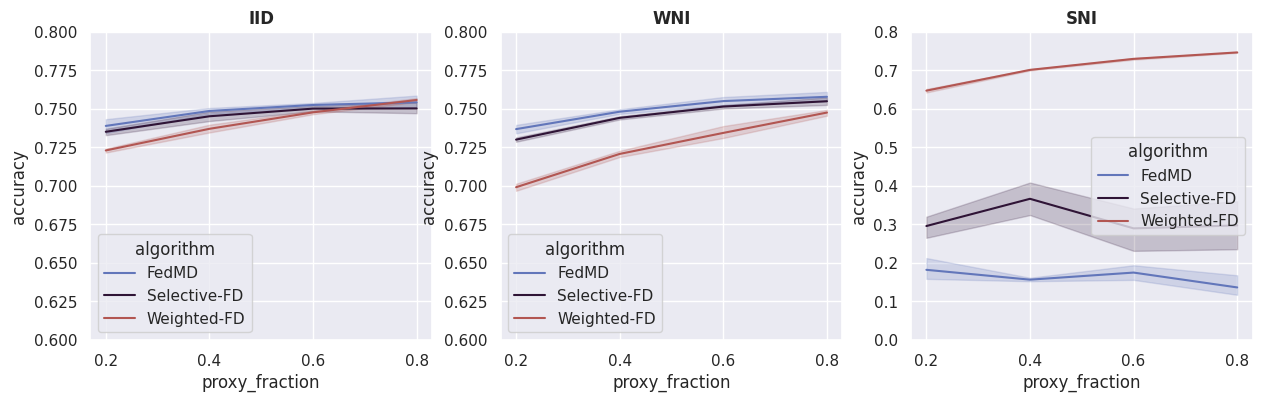

In [8]:
cifar10_plot_df = df[ (df["mode"] == "test") & (df["dataset"] == "CIFAR10") ]  \
            .groupby(["round", "algorithm", "dataset_type", "seed", "proxy_fraction"]) \
            .accuracy.mean().reset_index()

plot_convergence(cifar10_plot_df, lambda dataset_type : [0.6, 0.8] if dataset_type != 'hni' else [0., 0.8])

Table figure

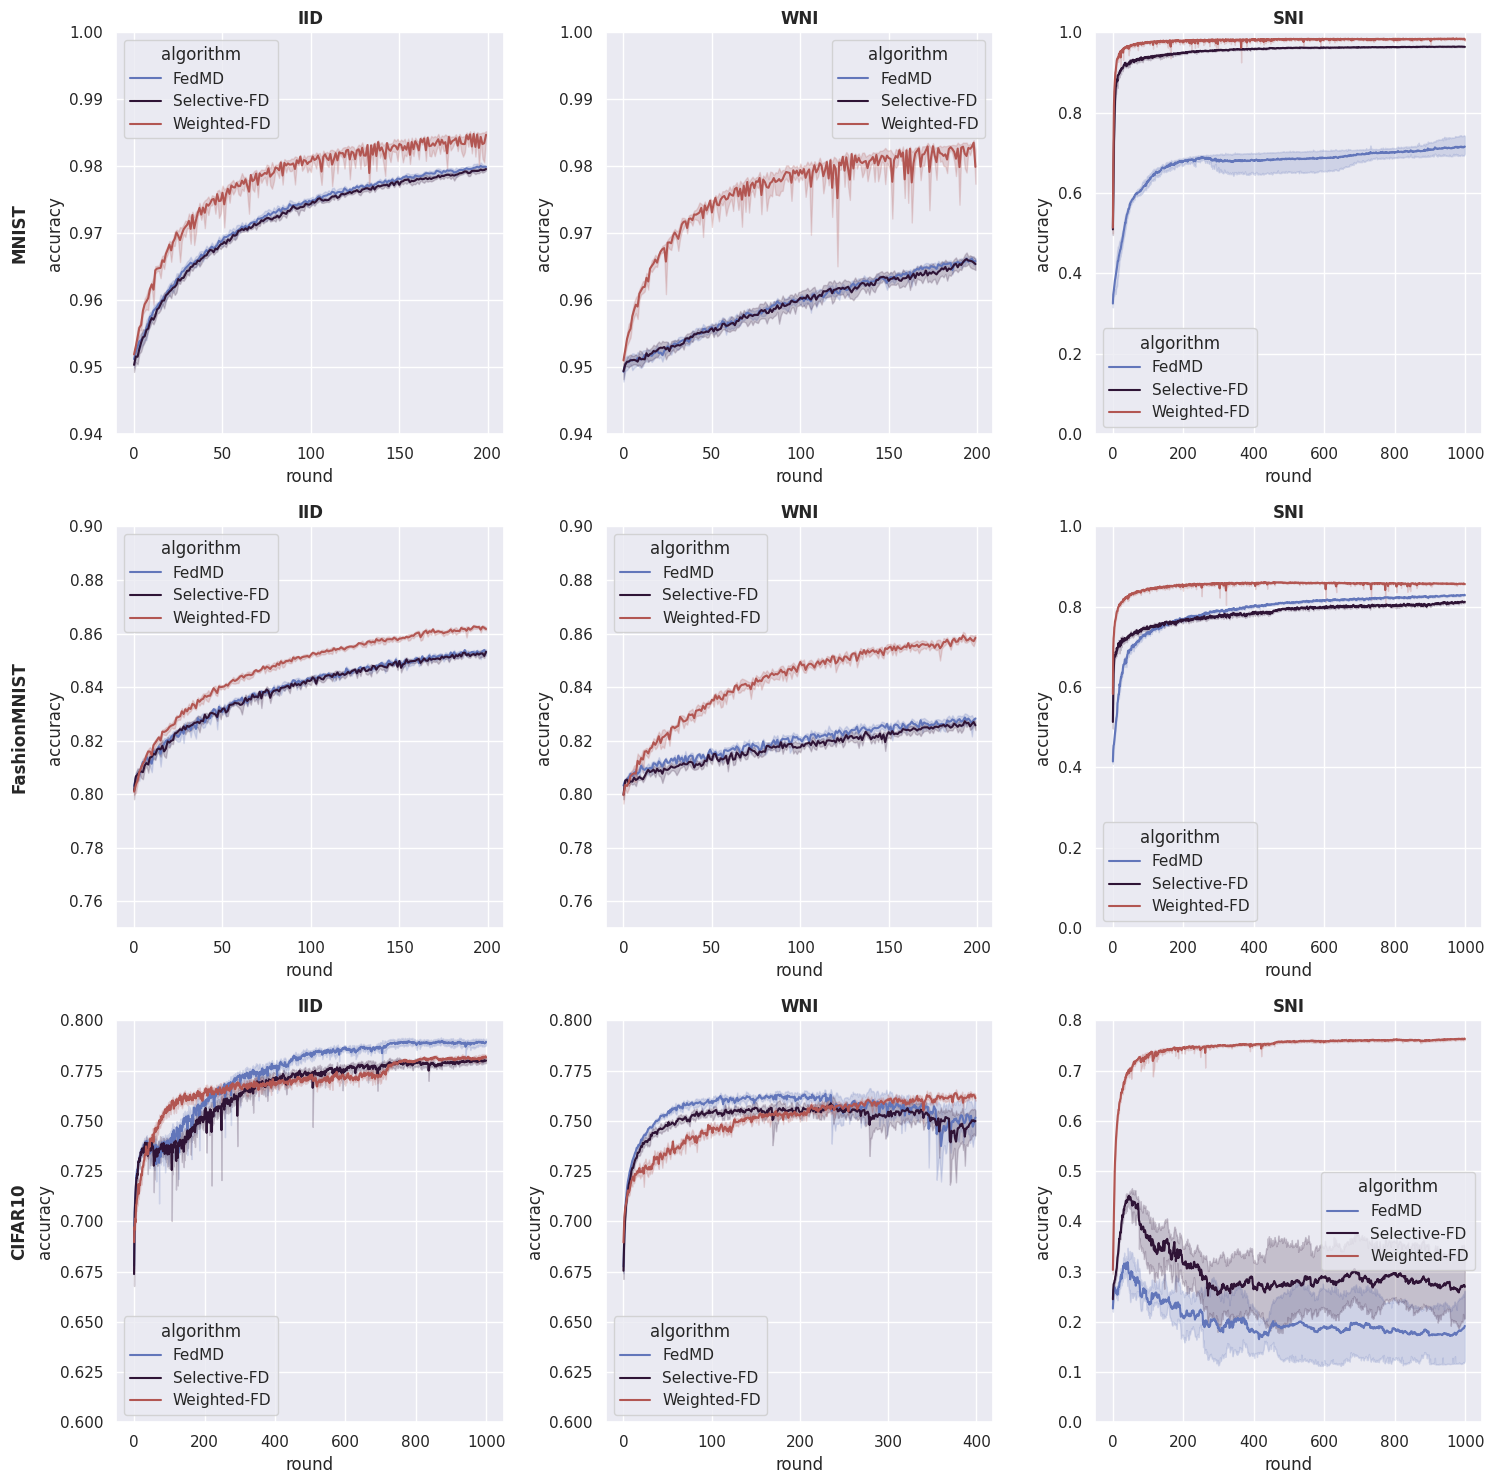

In [20]:
_, ax = plt.subplots(nrows=3, ncols=3, figsize=(15, 15))

plot_convergence_ax(mnist_plot_df, lambda dataset_type : [0.94, 1.00] if dataset_type != 'hni' else [0., 1.00], ax=ax[0])
plot_convergence_ax(fashion_plot_df, lambda dataset_type : [0.75, 0.90] if dataset_type != 'hni' else [0., 1.00], ax=ax[1])
plot_convergence_ax(cifar10_plot_df, lambda dataset_type : [0.6, 0.8] if dataset_type != 'hni' else [0., 0.8], ax=ax[2])

ax[0,0].text(-0.275, 0.5, 'MNIST', rotation=90, fontsize=12, weight='bold', transform=ax[0,0].transAxes, verticalalignment='center')
ax[1,0].text(-0.275, 0.5, 'FashionMNIST', rotation=90, fontsize=12, weight='bold', transform=ax[1,0].transAxes, verticalalignment='center')
ax[2,0].text(-0.275, 0.5, 'CIFAR10', rotation=90, fontsize=12, weight='bold', transform=ax[2,0].transAxes, verticalalignment='center')

plt.tight_layout()
plt.savefig("../ignore/convergence.pdf", format='pdf')
plt.show()